In [91]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import lissa as li

from sktime.transformations.series.vmd import VmdTransformer
from scipy.signal import hilbert

In [96]:
baseData = li.DataPreparer("../data","full_sensor_1h [old].csv")
entireData,pumpList = li.FailureMerge(baseData,"../data","respostas.csv")
entireData = li.FeatureCreation(entireData)

Headers = [
    "ESP Vibration X",
    "ESP Vibration Y",
    ]

número de bombas: 38
número de runs: 57


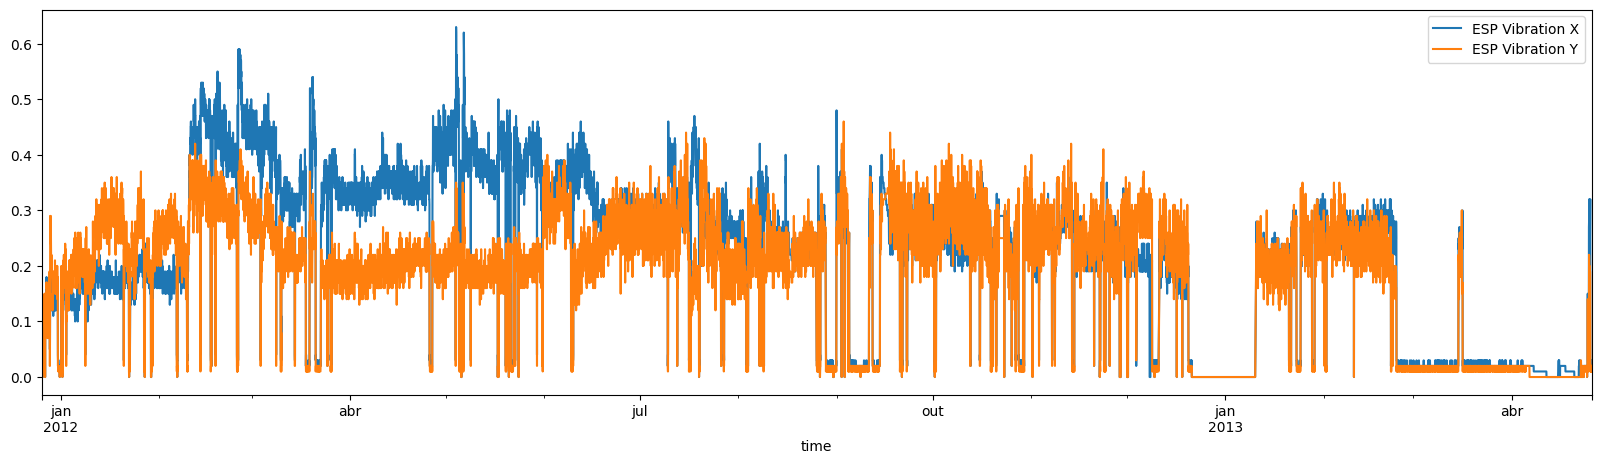

In [322]:
pump = pumpList[0]
entirePumpData = entireData.groupby("Well Run").get_group(pump)
pumpData = entirePumpData[Headers]

pumpData.plot(figsize=(20,5))

testData = (entirePumpData.groupby("Well_down")[Headers]
 .apply(lambda x: x.ewm(span=8).mean()-x.expanding().mean())
 .reset_index()
 .set_index("time")
 .drop(columns="Well_down")
 .sort_index())

In [323]:
# pumpData.hist(bins=40,figsize=(20,5))
# pumpData.diff().hist(bins=50,figsize=(20,5))
# pumpData.diff().plot(figsize=(20,5))
# plt.figure()
# pumpData.pow(2).sum(axis=1).diff().hist(bins=50,figsize=(20,5))
# pumpData = entireData.groupby("Well Run").get_group("B-10 1")[Headers]
# plt.figure()
# plt.scatter(pumpData["ESP Vibration X"].diff(),pumpData["ESP Vibration Y"].diff())


/tmp/ipykernel_94735/880285202.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=10)


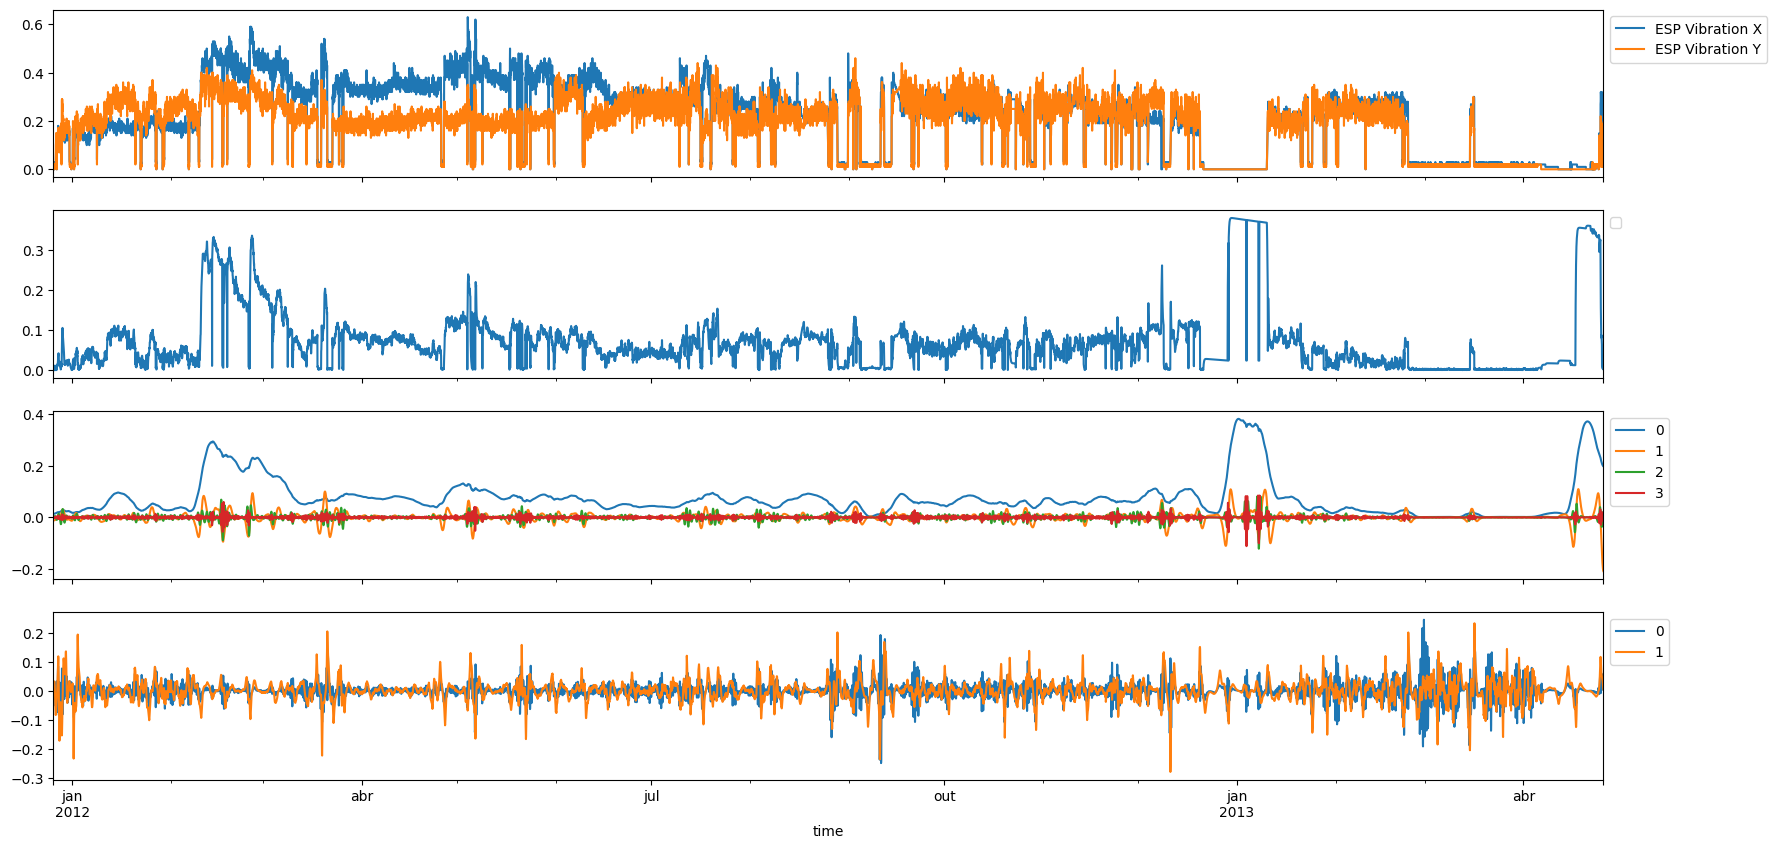

In [324]:
vmdModel = VmdTransformer(K=4,returned_decomp="u")
#prop = "ESP discharge pressure"

data = testData.pow(2).sum(axis=1).pow(1/2)

test = vmdModel.fit_transform(data)

test.index = data.index

angle = np.unwrap(np.angle(hilbert(test)))
instantAngle = pd.DataFrame(angle,index=data.index).diff()

fig,axs = plt.subplots(4,1)


pumpData.plot(ax=axs[0],sharex=True)

data.plot(ax=axs[1],figsize=(20,10),legend="yes")

(test).plot(ax=axs[2])
instantAngle[[0,1]].plot(ax=axs[3])

axs[0].legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=10)
axs[1].legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=10)
axs[2].legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=10)
axs[3].legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=10)


In [275]:
pump

'B-18 1'

array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
       [<Axes: title={'center': '2'}>, <Axes: title={'center': '3'}>]],
      dtype=object)

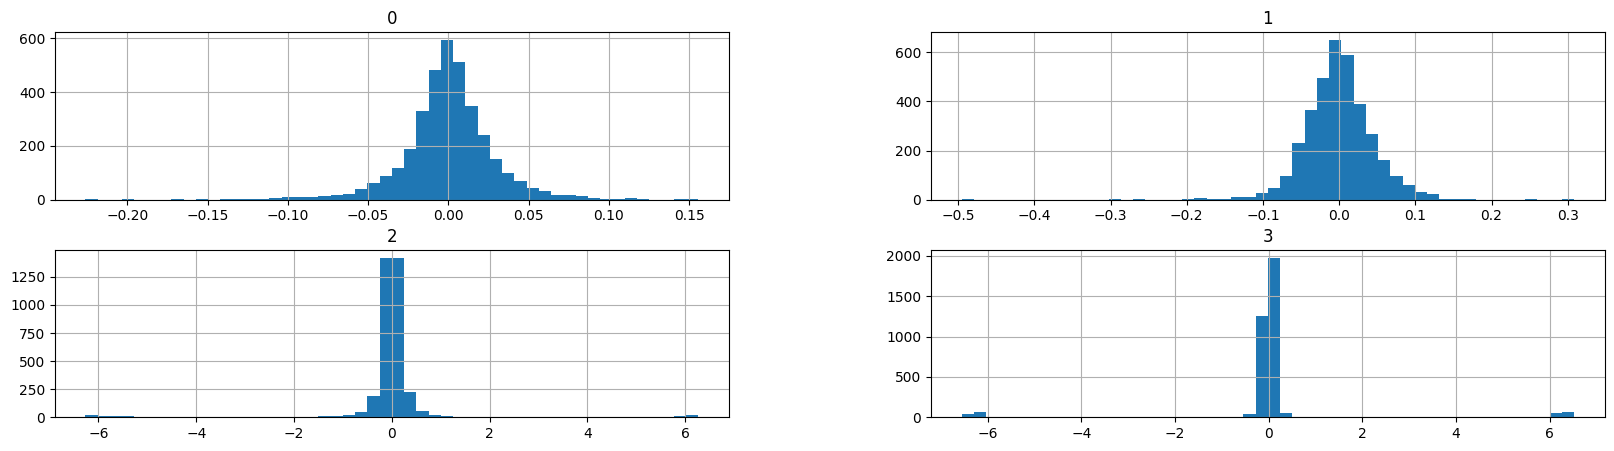

In [299]:
instantAngle.hist(bins=50,figsize=(20,5))

In [88]:
#cointegração

H = pumpData.diff().fillna(0)

A = (H[["ESP Vibration X"]].T)@H[["ESP Vibration X"]]
b = (H[["ESP Vibration X"]].T)@H[["ESP Vibration Y"]]

np.linalg.solve(A,b)

array([[1.10096093]])

array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
       [<Axes: title={'center': '2'}>, <Axes: title={'center': '3'}>]],
      dtype=object)

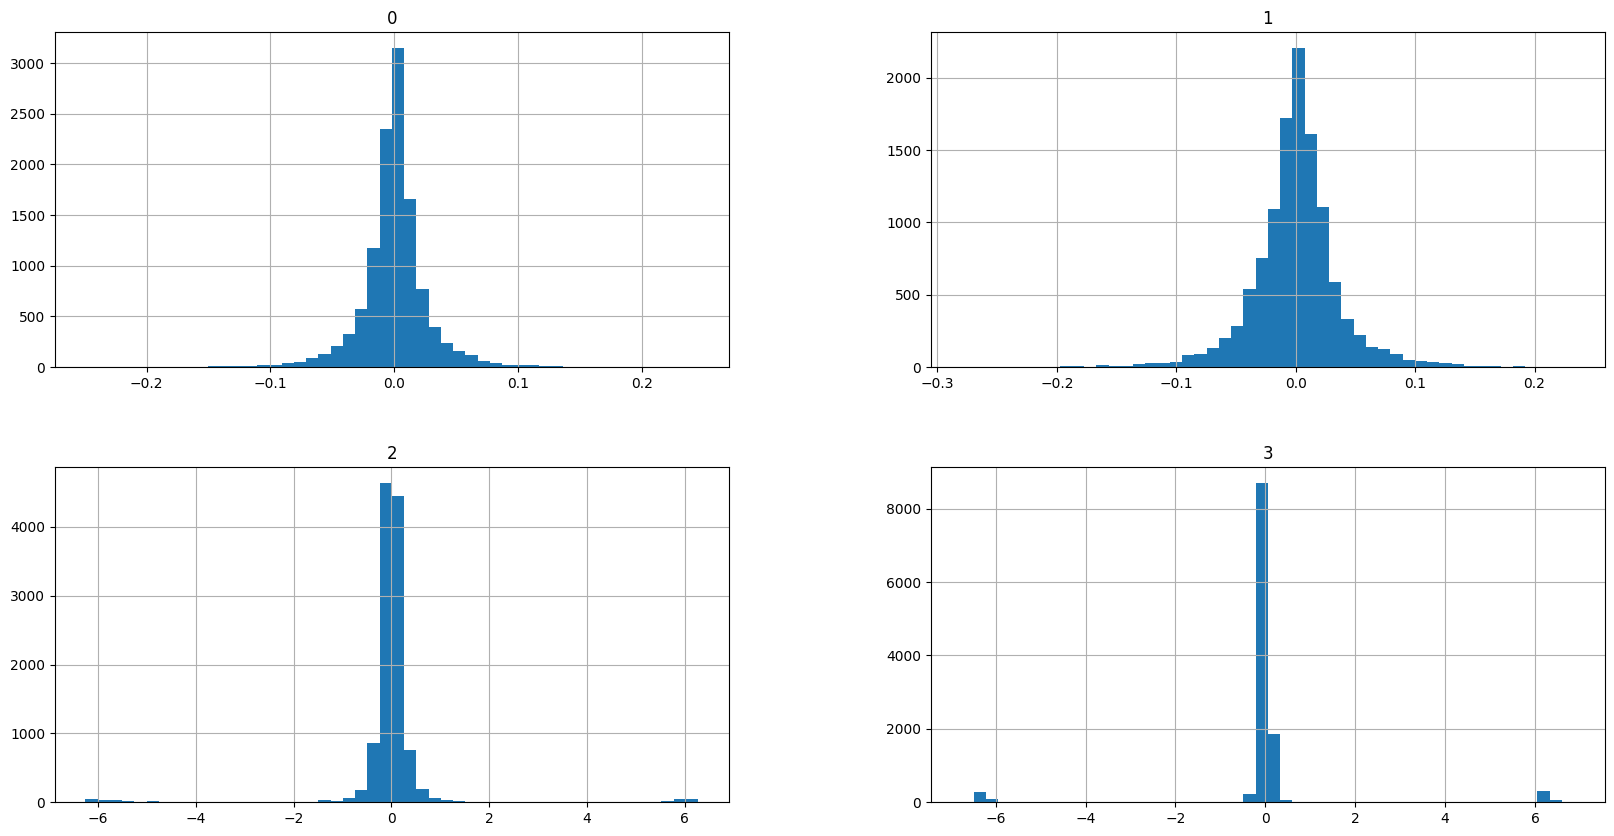

In [226]:
instantAngle.hist(bins=50,figsize=(20,10))

In [228]:
test[[0,1,2,3]]

,0,1,2,3
time,,,,
2011-12-26 02:00:00+00:00,0.014032,-0.011568,-0.004229,0.001755
2011-12-26 03:00:00+00:00,0.014033,-0.011567,-0.003981,0.001501
2011-12-26 04:00:00+00:00,0.014036,-0.011563,-0.003499,0.001006
2011-12-26 05:00:00+00:00,0.014039,-0.011557,-0.002808,0.000308
2011-12-26 06:00:00+00:00,0.014045,-0.011546,-0.001945,-0.000516
...,...,...,...,...
2013-04-25 23:00:00+00:00,0.199906,-0.194371,0.007949,-0.007821
2013-04-26 00:00:00+00:00,0.198950,-0.199286,0.013047,-0.003162
2013-04-26 01:00:00+00:00,0.198140,-0.203126,0.016916,0.001621


In [244]:
Sxx

array([[2.78101151e-05, 1.44196058e-05, 6.62241841e-05, ...,
        3.90001856e-08, 3.50671678e-03, 6.49079383e-03],
       [2.83863095e-03, 7.94458570e-03, 2.79336523e-03, ...,
        6.44390660e-05, 2.12410766e-03, 2.55389074e-02],
       [7.80897458e-03, 1.19719587e-02, 2.23874801e-03, ...,
        1.72258178e-05, 6.78541205e-03, 5.16309482e-01],
       ...,
       [8.16691082e-12, 3.48032187e-10, 2.12661755e-11, ...,
        2.91559904e-13, 2.41276918e-13, 5.98154524e-11],
       [1.66538091e-10, 7.35103559e-11, 2.97652414e-10, ...,
        8.09930864e-13, 3.82819517e-13, 1.10274279e-10],
       [2.71756382e-11, 3.44667103e-12, 6.50331922e-11, ...,
        2.52850560e-13, 4.61560118e-13, 1.56292040e-12]], shape=(129, 52))

Text(0.5, 0, 'Time [sec]')

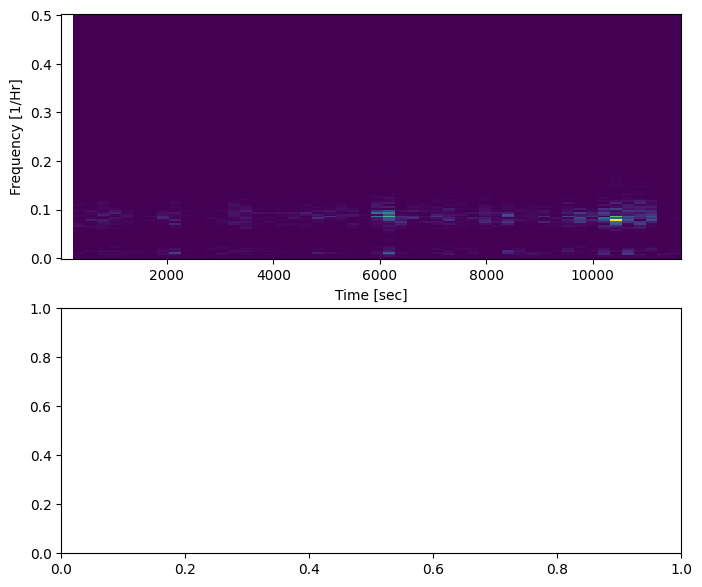

In [248]:
from scipy import signal
fig, ax = plt.subplots(2, figsize=(8, 7))

f, t, Sxx = signal.spectrogram(instantAngle[0], 1)
ax[0].pcolormesh(t, f, Sxx)
ax[0].set_ylabel('Frequency [1/Hr]')
ax[0].set_xlabel('Time [sec]')

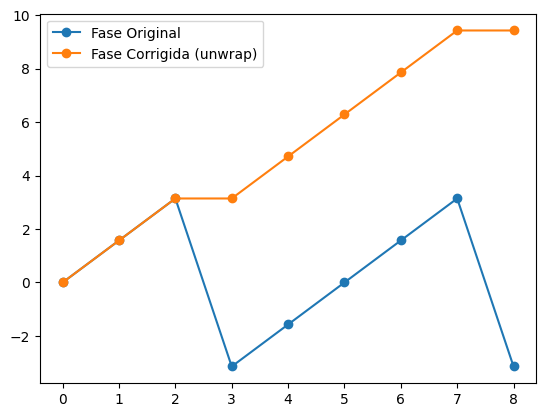

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Criando um vetor de fases com saltos de 2π
phase = np.array([0, np.pi/2, np.pi, -np.pi, -np.pi/2, 0, np.pi/2, np.pi, -np.pi])

# Aplicando np.unwrap
unwrapped_phase = np.unwrap(phase)

# Plotando
plt.plot(phase, 'o-', label="Fase Original")
plt.plot(unwrapped_phase, 'o-', label="Fase Corrigida (unwrap)")
plt.legend()
plt.show()


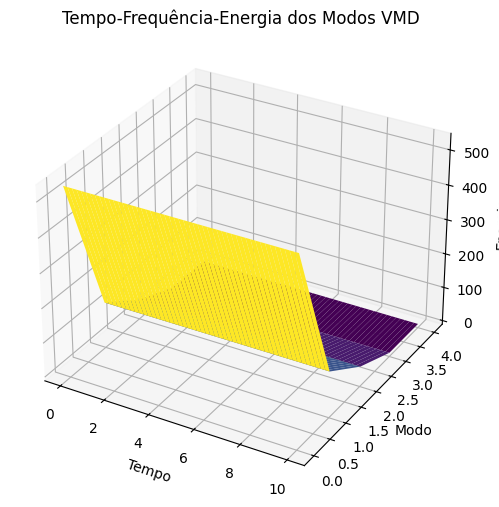

In [216]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# Simulação de um sinal com anomalias
np.random.seed(42)
t = np.linspace(0, 10, 1000)
signal = np.sin(2 * np.pi * 3 * t) + 0.5 * np.sin(2 * np.pi * 10 * t)
signal[500:520] += 2  # Criando uma anomalia artificial

# Aplicar VMD
vmd = VmdTransformer(K=5)  # Definir 5 modos
modes = pd.DataFrame(vmd.fit_transform(signal))

# Inicializar listas para armazenar frequência e energia
frequencies = []
energies = []

# Calcular frequência instantânea e energia para cada modo
for mode in modes.columns:
    mode_signal = modes[mode].values
    analytic_signal = hilbert(mode_signal)  # Transformada de Hilbert
    instantaneous_frequency = np.diff(np.unwrap(np.angle(analytic_signal))) / (2 * np.pi * np.diff(t))
    
    # Energia do modo
    energy = np.sum(mode_signal**2)
    
    # Salvar valores
    frequencies.append(instantaneous_frequency)
    energies.append(np.full_like(instantaneous_frequency, energy))  # Energia constante no tempo

# Converter listas para arrays
frequencies = np.array(frequencies)
energies = np.array(energies)

# Criar um gráfico 3D de tempo-frequência-energia
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Criar grid de tempo e frequência
T, F = np.meshgrid(t[1:], np.arange(frequencies.shape[0]))

# Plotar superfície 3D
ax.plot_surface(T, F, energies, cmap='viridis')

ax.set_xlabel("Tempo")
ax.set_ylabel("Modo")
ax.set_zlabel("Energia")
ax.set_title("Tempo-Frequência-Energia dos Modos VMD")

plt.show()


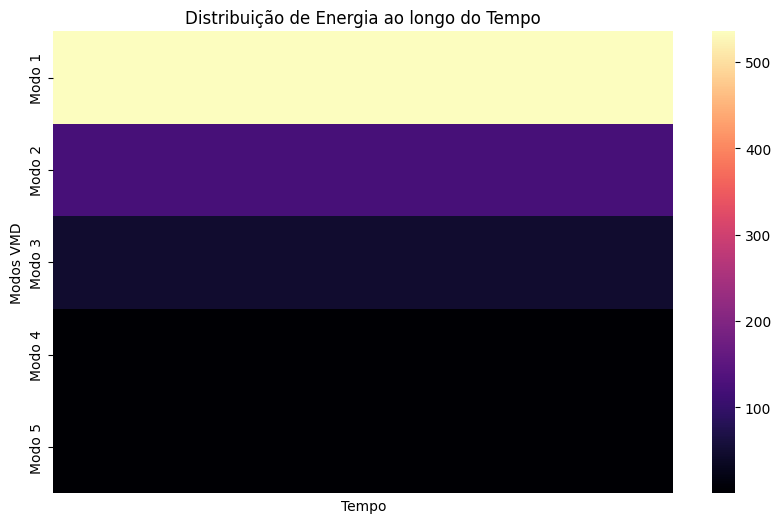

In [217]:
import seaborn as sns

# Criar heatmap de energia
plt.figure(figsize=(10, 6))
sns.heatmap(energies, cmap="magma", xticklabels=False, yticklabels=[f"Modo {i+1}" for i in range(len(modes.columns))])
plt.xlabel("Tempo")
plt.ylabel("Modos VMD")
plt.title("Distribuição de Energia ao longo do Tempo")
plt.show()
